# SPIE Abstract — 3-Model Comparison (17 Patients, v8)

Compares 3 models on all 17 hold-out PD patients (10 D1 + 7 new).

| Model | Checkpoint | Training data | Purpose |
|---|---|---|---|
| **v8_baseline** | baseline_best_model.pth | DESS only (no PD) | Zero-shot cross-modality |
| **v8_pseudoPD** | run_002_v2/ckpt_best.pth | Fake PD only (RegGAN) | Transfer via synthetic PD |
| **v8_mixed** | run_v7_mixed/ckpt_best.pth | Real PD (15pt) + fake PD | Best combined model |


In [1]:
import os
import glob
import re
import numpy as np
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES  = f"{BASE}/results/final_results"

PD_DIR      = "/Users/anshikabajpai/Desktop/AImed-lab/IU-Dess-dataset/iu-dataset/pd-files"
GT_DIR_D1   = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final"
GT_DIR_NEW  = "/Users/anshikabajpai/Downloads/segmentations"

PRED_BASELINE_DIR  = f"{RES}/real_pd_predictions_v8_baseline"
PRED_PSEUDOPD_DIR  = f"{RES}/real_pd_predictions_v8_pseudoPD"
PRED_MIXED_DIR     = f"{RES}/real_pd_predictions_v8_mixed"

D1_PATIENTS = [
    "AC0D5A4D78B628", "AC0D7BF72F7712", "AC0D3459553205", "AC14D3737C0482",
    "AC19E7C19827FF", "AC149BC218E75C", "AC111633B463BB", "AC13300201B926",
    "AC12026D14291F", "AC13637DA25399",
]
NEW_PATIENTS = [
    "AC000550763509", "AC005135D3495B", "AC04433E37DB66", "AC056ADCE8BE28",
    "AC07607B9E5295", "AC0D1A9818A6FC", "AC0F11041F5180",
]
ALL_PATIENTS = D1_PATIENTS + NEW_PATIENTS
print(f"Total: {len(ALL_PATIENTS)} patients (D1={len(D1_PATIENTS)}, new={len(NEW_PATIENTS)})")

Total: 17 patients (D1=10, new=7)


In [3]:
# ── Helper functions ───────────────────────────────────────────────────────
def get_pid(fname):
    m = re.match(r"(AC[A-F0-9]+)", os.path.basename(fname), re.IGNORECASE)
    return m.group(1) if m else None

def patients_in_dir(directory, pattern="*.nii.gz"):
    files = glob.glob(os.path.join(directory, pattern))
    return {get_pid(f): f for f in files if get_pid(f)}

def load_vol(path):
    return np.asarray(nib.load(path).get_fdata())

def load_nrrd_binary(path):
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    if arr.ndim == 4:
        arr = (arr.max(axis=0) > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        try:
            comp = sitk.VectorIndexSelectionCast(img, 0)
            out.CopyInformation(comp)
        except Exception:
            out.SetSpacing(img.GetSpacing()[:3]); out.SetOrigin(img.GetOrigin()[:3])
            out.SetDirection(img.GetDirection()[:9])
    else:
        arr = (arr > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        out.CopyInformation(img)
    try: out = sitk.DICOMOrient(out, "RAS")
    except Exception: pass
    sp  = out.GetSpacing()
    arr = sitk.GetArrayFromImage(out).astype(np.float32).transpose(2, 1, 0)
    fa  = float(sp[1]) / min(sp[1], sp[2])
    fs  = float(sp[2]) / min(sp[1], sp[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384/n_A, 384/n_S), order=0)
    return (arr > 0.5).astype(bool)

def preprocess_pd_image(path):
    img   = nib.as_closest_canonical(nib.load(path))
    arr   = img.get_fdata().astype(np.float32)
    zooms = img.header.get_zooms()[:3]
    fa    = float(zooms[1]) / min(zooms[1], zooms[2])
    fs    = float(zooms[2]) / min(zooms[1], zooms[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=3)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384/n_A, 384/n_S), order=3)
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    arr = np.clip(arr, lo, hi)
    return (arr - lo) / (hi - lo + 1e-8)

def merge_meniscus(pred):
    return (pred > 0).astype(bool)

def dice_score(pred_bin, gt_bin):
    intersection = (pred_bin & gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    return float(2 * intersection / denom) if denom > 0 else 1.0

def best_class_dice(pred_5class, gt_bin):
    best_d, best_c = -1.0, -1
    for c in range(1, 5):
        d = dice_score((pred_5class == c), gt_bin)
        if d > best_d:
            best_d, best_c = d, c
    return best_d, best_c

In [4]:
# ── Load GT masks and predictions ──────────────────────────────────────────
gt_masks = {}
for pid in ALL_PATIENTS:
    hits = glob.glob(os.path.join(GT_DIR_D1,  f"{pid}*.seg.nrrd")) or \
           glob.glob(os.path.join(GT_DIR_NEW, f"{pid}*.seg.nrrd"))
    if hits: gt_masks[pid] = hits[0]
    else: print(f"WARNING: No GT for {pid}")
print(f"GT masks found: {len(gt_masks)}/17")

baseline_preds = patients_in_dir(PRED_BASELINE_DIR)
pseudopd_preds = patients_in_dir(PRED_PSEUDOPD_DIR)
mixed_preds    = patients_in_dir(PRED_MIXED_DIR)
print(f"v8_baseline : {len(baseline_preds)} patients")
print(f"v8_pseudoPD : {len(pseudopd_preds)} patients")
print(f"v8_mixed    : {len(mixed_preds)} patients")

GT masks found: 17/17
v8_baseline : 17 patients
v8_pseudoPD : 17 patients
v8_mixed    : 17 patients


In [5]:
# ── Compute Dice ───────────────────────────────────────────────────────────
results = []
run_names = ["baseline", "pseudoPD", "mixed"]

for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        print(f"SKIP {pid}"); continue

    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new", "_gt": gt_bin}

    # Baseline (5-class)
    if pid in baseline_preds:
        pred_b = load_vol(baseline_preds[pid]).astype(np.int16)
        d_b, best_c = best_class_dice(pred_b, gt_bin)
        row["dice_baseline"] = d_b; row["baseline_class"] = best_c
        row["_pred_baseline"] = pred_b; row["_pred_baseline_bin"] = (pred_b == best_c)
    else:
        row["dice_baseline"] = float("nan"); row["_pred_baseline"] = None

    # v8_pseudoPD (3-class — run_002_v2 ckpt)
    if pid in pseudopd_preds:
        pred_p = load_vol(pseudopd_preds[pid])
        row["dice_pseudoPD"] = dice_score(merge_meniscus(pred_p), gt_bin)
        row["_pred_pseudoPD"] = pred_p
    else:
        row["dice_pseudoPD"] = float("nan"); row["_pred_pseudoPD"] = None

    # v8_mixed (3-class — v7_mixed ckpt)
    if pid in mixed_preds:
        pred_m = load_vol(mixed_preds[pid])
        row["dice_mixed"] = dice_score(merge_meniscus(pred_m), gt_bin)
        row["_pred_mixed"] = pred_m
    else:
        row["dice_mixed"] = float("nan"); row["_pred_mixed"] = None

    results.append(row)
    print(f"{pid} ({row['cohort']})  "
          f"baseline={row['dice_baseline']:.3f}  "
          f"pseudoPD={row['dice_pseudoPD']:.3f}  "
          f"mixed={row['dice_mixed']:.3f}")

means = {}
for rn in run_names:
    vals = [r[f"dice_{rn}"] for r in results if not np.isnan(r.get(f"dice_{rn}", float("nan")))]
    means[rn] = np.mean(vals) if vals else float("nan")
print(f"\nMEAN — baseline={means['baseline']:.4f}  pseudoPD={means['pseudoPD']:.4f}  mixed={means['mixed']:.4f}")

AC0D5A4D78B628 (D1)  baseline=0.000  pseudoPD=0.601  mixed=0.709
AC0D7BF72F7712 (D1)  baseline=0.000  pseudoPD=0.696  mixed=0.777
AC0D3459553205 (D1)  baseline=0.000  pseudoPD=0.659  mixed=0.725
AC14D3737C0482 (D1)  baseline=0.000  pseudoPD=0.637  mixed=0.791
AC19E7C19827FF (D1)  baseline=0.000  pseudoPD=0.705  mixed=0.802
AC149BC218E75C (D1)  baseline=0.000  pseudoPD=0.713  mixed=0.801
AC111633B463BB (D1)  baseline=0.000  pseudoPD=0.745  mixed=0.809
AC13300201B926 (D1)  baseline=0.000  pseudoPD=0.726  mixed=0.763
AC12026D14291F (D1)  baseline=0.001  pseudoPD=0.727  mixed=0.786
AC13637DA25399 (D1)  baseline=0.000  pseudoPD=0.741  mixed=0.808
AC000550763509 (new)  baseline=0.000  pseudoPD=0.735  mixed=0.809
AC005135D3495B (new)  baseline=0.000  pseudoPD=0.726  mixed=0.822
AC04433E37DB66 (new)  baseline=0.003  pseudoPD=0.673  mixed=0.728
AC056ADCE8BE28 (new)  baseline=0.000  pseudoPD=0.558  mixed=0.685
AC07607B9E5295 (new)  baseline=0.000  pseudoPD=0.671  mixed=0.843
AC0D1A9818A6FC (new)

In [6]:
# ── Summary table ──────────────────────────────────────────────────────────
import pandas as pd
rows = []
for r in results:
    rows.append({
        "Patient": r["patient"], "Cohort": r["cohort"],
        "Baseline": f"{r.get('dice_baseline', float('nan')):.4f}",
        "Pseudo PD (run_002_v2)": f"{r.get('dice_pseudoPD', float('nan')):.4f}",
        "Mixed (v7_mixed)":       f"{r.get('dice_mixed',   float('nan')):.4f}",
    })
df = pd.DataFrame(rows)
display(df)
print(f"\nMEAN  baseline={means['baseline']:.4f}  pseudoPD={means['pseudoPD']:.4f}  mixed={means['mixed']:.4f}")

,Patient,Cohort,Baseline,Pseudo PD (run_002_v2),Mixed (v7_mixed)
0,AC0D5A4D78B628,D1,0.0000,0.6013,0.7093
1,AC0D7BF72F7712,D1,0.0000,0.6962,0.7771
2,AC0D3459553205,D1,0.0000,0.6590,0.7250
3,AC14D3737C0482,D1,0.0002,0.6375,0.7906
4,AC19E7C19827FF,D1,0.0000,0.7052,0.8025
5,AC149BC218E75C,D1,0.0000,0.7134,0.8009
6,AC111633B463BB,D1,0.0000,0.7449,0.8094
7,AC13300201B926,D1,0.0000,0.7260,0.7626
8,AC12026D14291F,D1,0.0014,0.7272,0.7862
9,AC13637DA25399,D1,0.0000,0.7415,0.8084



MEAN  baseline=0.0003  pseudoPD=0.6870  mixed=0.7812


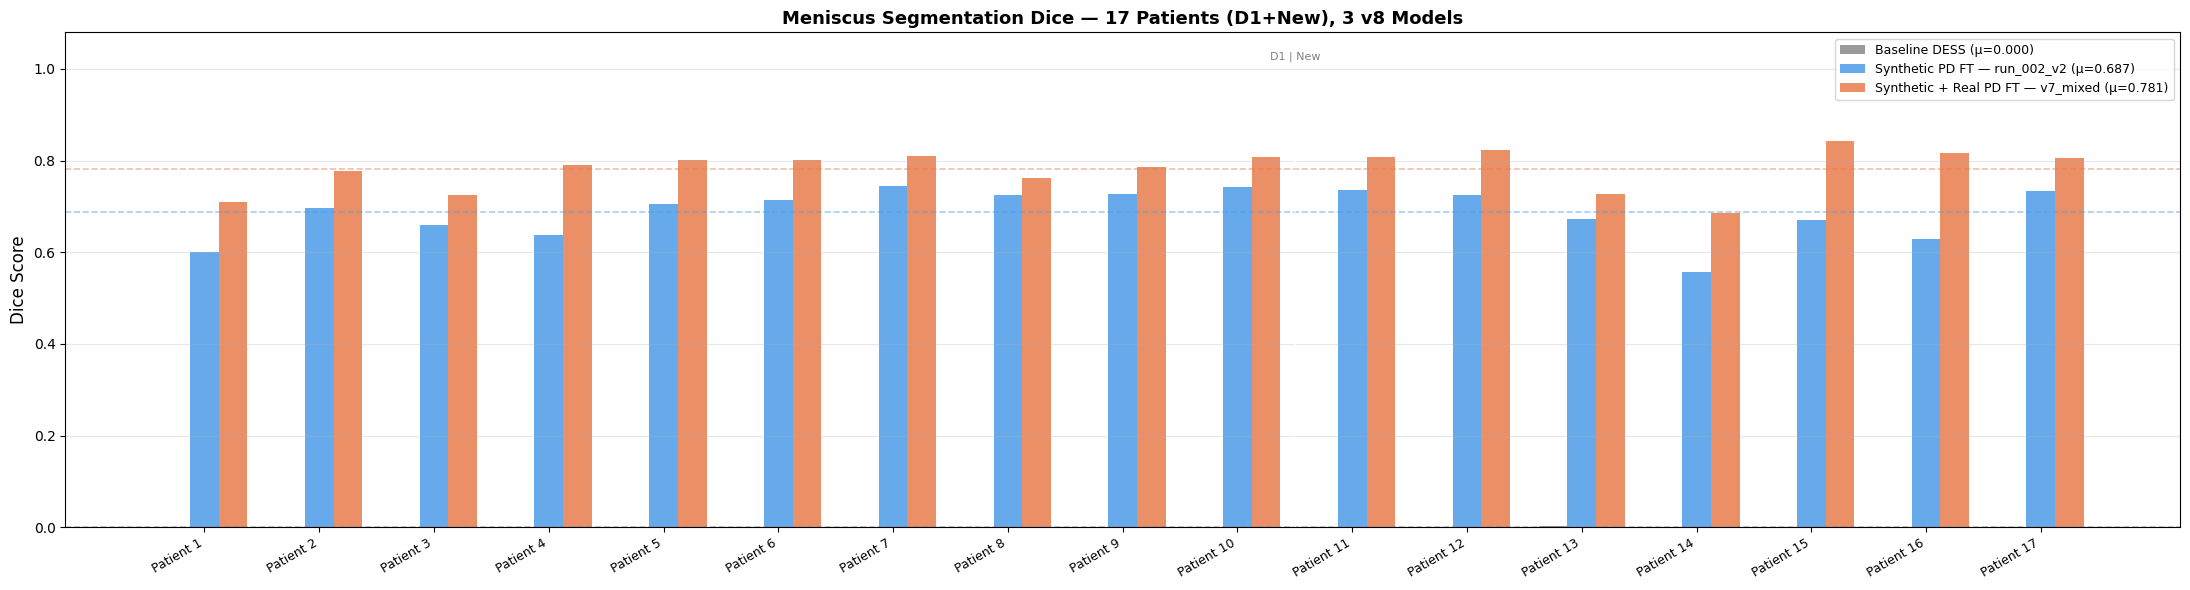

Saved → dice_abstract_v8_3models.png


In [7]:
# ── Bar chart ──────────────────────────────────────────────────────────────
COLORS = {"baseline": "#888888", "pseudoPD": "#4C9BE8", "mixed": "#E87B4C"}
LABELS = {
    "baseline":  f"Baseline DESS (μ={means['baseline']:.3f})",
    "pseudoPD":  f"Synthetic PD FT — run_002_v2 (μ={means['pseudoPD']:.3f})",
    "mixed":     f"Synthetic + Real PD FT — v7_mixed (μ={means['mixed']:.3f})",
}

x = np.arange(len(results))
w, offsets = 0.25, [-0.25, 0, 0.25]

fig, ax = plt.subplots(figsize=(22, 6))
for i, rn in enumerate(run_names):
    vals = [r.get(f"dice_{rn}", float("nan")) for r in results]
    ax.bar(x + offsets[i], vals, w, label=LABELS[rn], color=COLORS[rn], alpha=0.85)
    ax.axhline(means[rn], color=COLORS[rn], linestyle="--", alpha=0.5, linewidth=1.2)

# D1 / New separator
n_d1 = sum(1 for r in results if r["cohort"] == "D1")
ax.axvline(n_d1 - 0.5, color="white", linewidth=1.5, linestyle=":")
ax.text(n_d1 - 0.5, 1.02, "D1 | New", ha="center", fontsize=8, color="grey")

ax.set_xticks(x)
ax.set_xticklabels([f"Patient {i+1}" for i in range(len(results))], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Dice Score", fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_title("Meniscus Segmentation Dice — 17 Patients (D1+New), 3 v8 Models", fontweight="bold", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/dice_abstract_v8_3models.png", dpi=150)
plt.show()
print("Saved → dice_abstract_v8_3models.png")

In [8]:
# ── Panel selection: 2 good + 1 challenging ────────────────────────────────
sorted_by_mixed = sorted(results, key=lambda r: r.get("dice_mixed", 0), reverse=True)
panel_results = sorted_by_mixed[:2] + [sorted_by_mixed[-1]]
ROW_LABELS = ["Good case 1", "Good case 2", "Challenging case"]
print("Panel patients:")
for i, r in enumerate(panel_results):
    print(f"  {ROW_LABELS[i]}: {r['patient']}  mixed={r['dice_mixed']:.3f}")

Panel patients:
  Good case 1: AC07607B9E5295  mixed=0.843
  Good case 2: AC005135D3495B  mixed=0.822
  Challenging case: AC056ADCE8BE28  mixed=0.685


In [9]:
# ── Shared helpers for zoomed + overlay plots ──────────────────────────────
def get_zoom_bounds(gt_disp, pad=40):
    rows = np.where(np.any(gt_disp, axis=1))[0]
    cols = np.where(np.any(gt_disp, axis=0))[0]
    if len(rows) == 0 or len(cols) == 0:
        return 0, 383, 0, 383
    return (max(0, cols[0]-pad), min(383, cols[-1]+pad),
            max(0, rows[0]-pad), min(383, rows[-1]+pad))

def get_pred_bin(r, mk, sl):
    if mk == "baseline":
        return r["_pred_baseline_bin"][sl] if r.get("_pred_baseline") is not None else np.zeros((384,384),bool)
    elif mk == "pseudoPD":
        return merge_meniscus(r["_pred_pseudoPD"])[sl] if r.get("_pred_pseudoPD") is not None else np.zeros((384,384),bool)
    elif mk == "mixed":
        return merge_meniscus(r["_pred_mixed"])[sl] if r.get("_pred_mixed") is not None else np.zeros((384,384),bool)
    return np.zeros((384,384),bool)

def load_pd_sl(r, best_sl):
    pid = r["patient"]
    pd_files = glob.glob(os.path.join(PD_DIR, f"{pid}*.nii*"))
    pd_sl = np.zeros((384,384),float)
    if pd_files:
        pv = preprocess_pd_image(pd_files[0])
        if pv.shape[0] != r["_gt"].shape[0]:
            pv = zoom(pv, (r["_gt"].shape[0]/pv.shape[0], 1.0, 1.0), order=3)
        pd_sl = pv[best_sl]
    return pd_sl

PRED_COLORS = {"baseline": "#FF6B6B", "pseudoPD": "#00E5FF", "mixed": "#69FF47"}
MCOLORS     = {"baseline": "#FF4444", "pseudoPD": "#4C9BE8", "mixed": "#E87B4C"}
MLABELS     = {"baseline": "Baseline (DESS, no FT)", "pseudoPD": "Synthetic PD FT", "mixed": "Synthetic + Real PD FT"}
print("Helpers ready.")

Helpers ready.


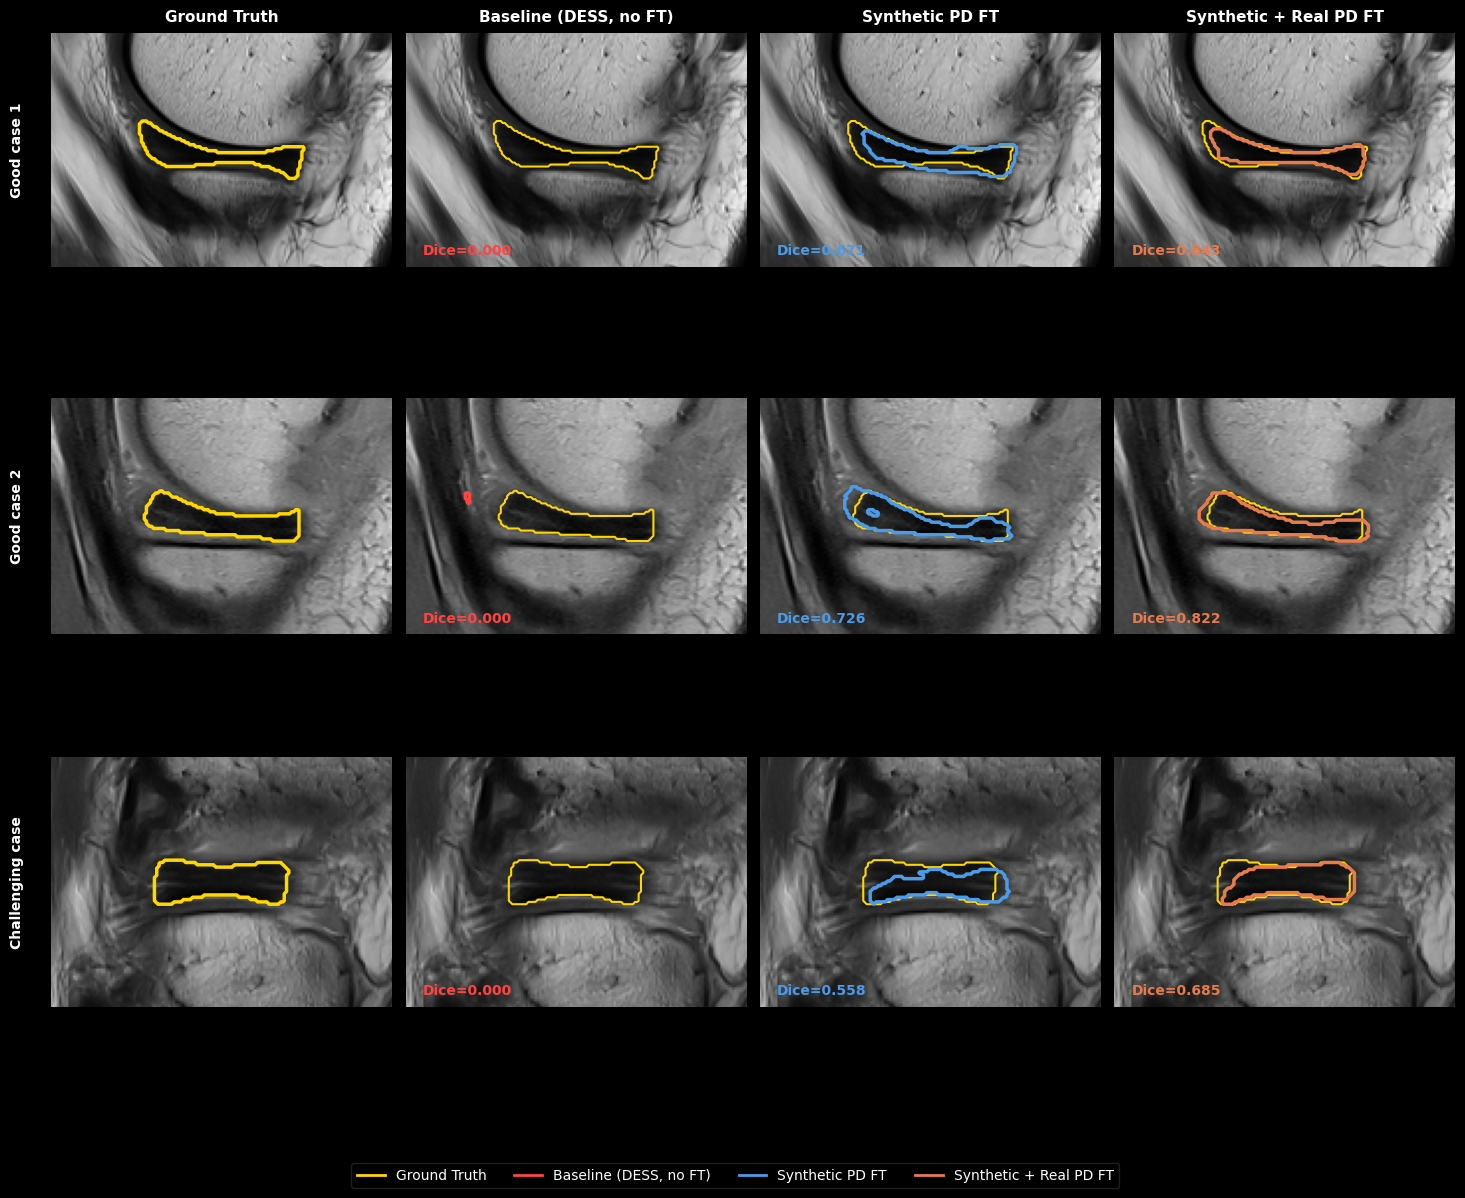

Saved → zoom_4panel_v8.png


In [10]:
# ── Plot 1: Zoomed 4-panel — GT | Baseline | Syn PD | Syn+Real PD ───────────
fig, axes = plt.subplots(3, 4, figsize=(18, 14), facecolor="black")
fig.subplots_adjust(hspace=0.06, wspace=0.04, left=0.12)

col_titles = ["Ground Truth", "Baseline (DESS, no FT)", "Synthetic PD FT", "Synthetic + Real PD FT"]
for ci, t in enumerate(col_titles):
    axes[0, ci].set_title(t, color="white", fontsize=11, fontweight="bold", pad=8)

for ri, r in enumerate(panel_results):
    gt_bin  = r["_gt"].astype(bool)
    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))
    pd_sl   = load_pd_sl(r, best_sl)
    gt_disp = gt_bin[best_sl].T
    x0, x1, y0, y1 = get_zoom_bounds(gt_disp, pad=45)

    for ci in range(4):
        ax = axes[ri, ci]
        ax.set_facecolor("black")
        ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.axis("off")

    axes[ri, 0].text(-0.08, 0.5, ROW_LABELS[ri], transform=axes[ri, 0].transAxes,
                     color="white", fontsize=10, fontweight="bold", rotation=90, va="center", ha="right")

    if gt_disp.any():
        axes[ri, 0].contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=2.5)

    for ci, mk in enumerate(["baseline", "pseudoPD", "mixed"], start=1):
        ax = axes[ri, ci]
        pred_d = get_pred_bin(r, mk, best_sl).T
        if gt_disp.any():
            ax.contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=1.5)
        if pred_d.any():
            ax.contour(pred_d, levels=[0.5], colors=[MCOLORS[mk]], linewidths=2.5)
        d = r.get(f"dice_{mk}", float("nan"))
        ax.text(0.05, 0.05, f"Dice={d:.3f}", transform=ax.transAxes,
                color=MCOLORS[mk], fontsize=10, fontweight="bold")

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], color="#FFD700", lw=2, label="Ground Truth")] + \
      [Line2D([0],[0], color=MCOLORS[mk], lw=2, label=MLABELS[mk]) for mk in ["baseline","pseudoPD","mixed"]]
fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=10,
           framealpha=0.15, labelcolor="white", facecolor="black", bbox_to_anchor=(0.5, 0.01))
plt.savefig(f"{BASE}/zoom_4panel_v8.png", dpi=150, facecolor="black", bbox_inches="tight")
plt.show()
print("Saved → zoom_4panel_v8.png")

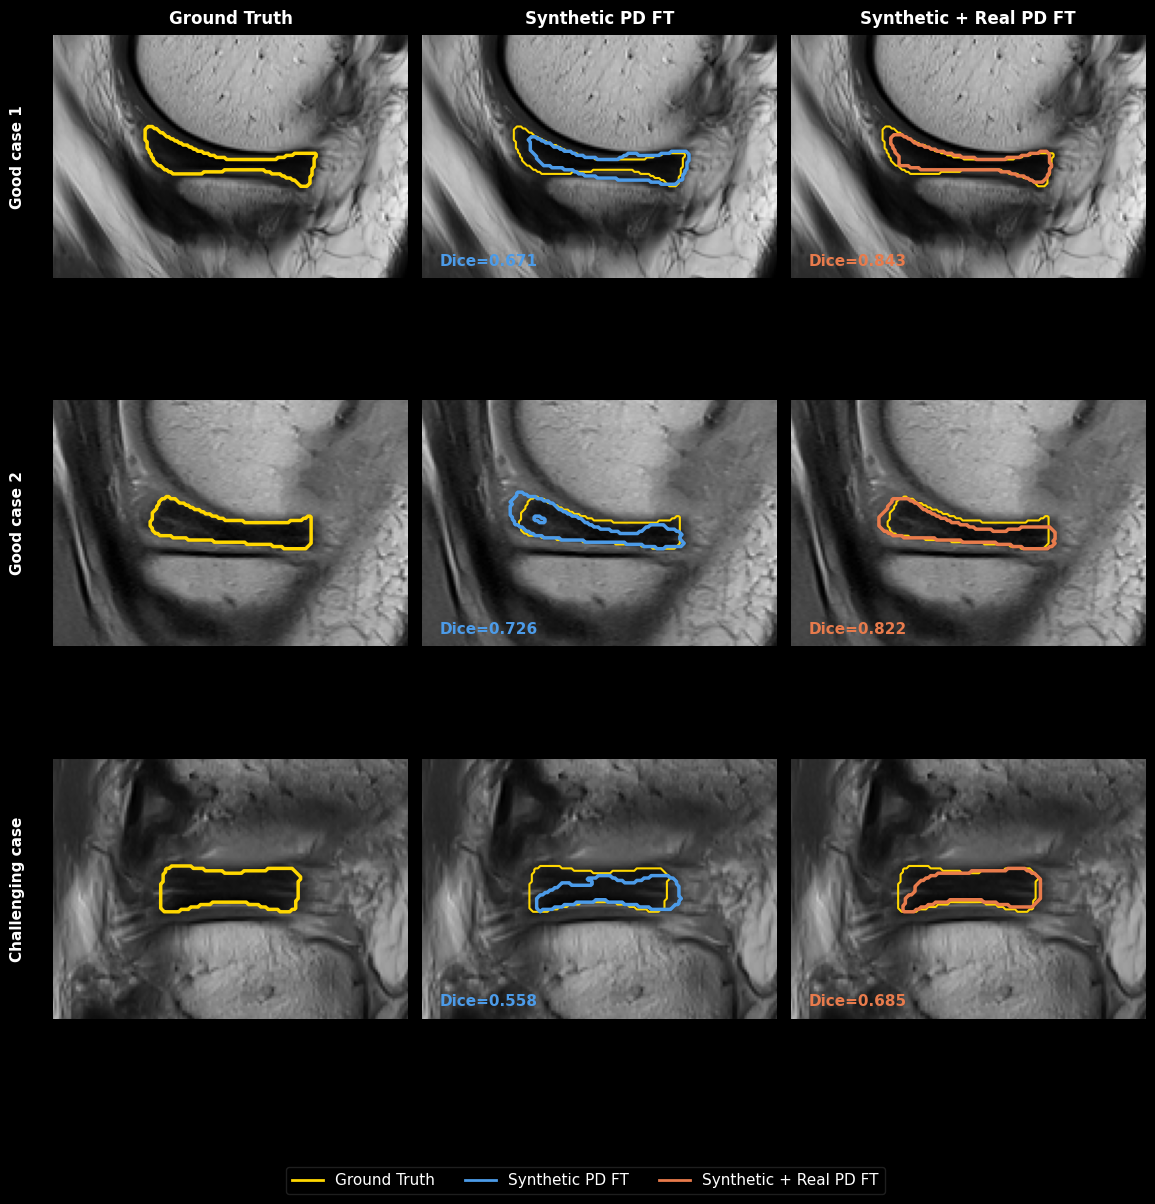

Saved → zoom_3panel_v8.png


In [11]:
# ── Plot 2: Zoomed 3-panel — GT | Syn PD | Syn+Real PD ──────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 14), facecolor="black")
fig.subplots_adjust(hspace=0.06, wspace=0.04, left=0.12)

col_titles = ["Ground Truth", "Synthetic PD FT", "Synthetic + Real PD FT"]
for ci, t in enumerate(col_titles):
    axes[0, ci].set_title(t, color="white", fontsize=12, fontweight="bold", pad=8)

for ri, r in enumerate(panel_results):
    gt_bin  = r["_gt"].astype(bool)
    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))
    pd_sl   = load_pd_sl(r, best_sl)
    gt_disp = gt_bin[best_sl].T
    x0, x1, y0, y1 = get_zoom_bounds(gt_disp, pad=45)

    for ci in range(3):
        ax = axes[ri, ci]
        ax.set_facecolor("black")
        ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.axis("off")

    axes[ri, 0].text(-0.08, 0.5, ROW_LABELS[ri], transform=axes[ri, 0].transAxes,
                     color="white", fontsize=11, fontweight="bold", rotation=90, va="center", ha="right")

    if gt_disp.any():
        axes[ri, 0].contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=2.5)

    for ci, mk in enumerate(["pseudoPD", "mixed"], start=1):
        ax = axes[ri, ci]
        pred_d = get_pred_bin(r, mk, best_sl).T
        if gt_disp.any():
            ax.contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=1.5)
        if pred_d.any():
            ax.contour(pred_d, levels=[0.5], colors=[MCOLORS[mk]], linewidths=2.5)
        d = r.get(f"dice_{mk}", float("nan"))
        ax.text(0.05, 0.05, f"Dice={d:.3f}", transform=ax.transAxes,
                color=MCOLORS[mk], fontsize=11, fontweight="bold")

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], color="#FFD700", lw=2, label="Ground Truth"),
       Line2D([0],[0], color=MCOLORS["pseudoPD"], lw=2, label=MLABELS["pseudoPD"]),
       Line2D([0],[0], color=MCOLORS["mixed"],    lw=2, label=MLABELS["mixed"])]
fig.legend(handles=leg, loc="lower center", ncol=3, fontsize=11,
           framealpha=0.15, labelcolor="white", facecolor="black", bbox_to_anchor=(0.5, 0.01))
plt.savefig(f"{BASE}/zoom_3panel_v8.png", dpi=150, facecolor="black", bbox_inches="tight")
plt.show()
print("Saved → zoom_3panel_v8.png")

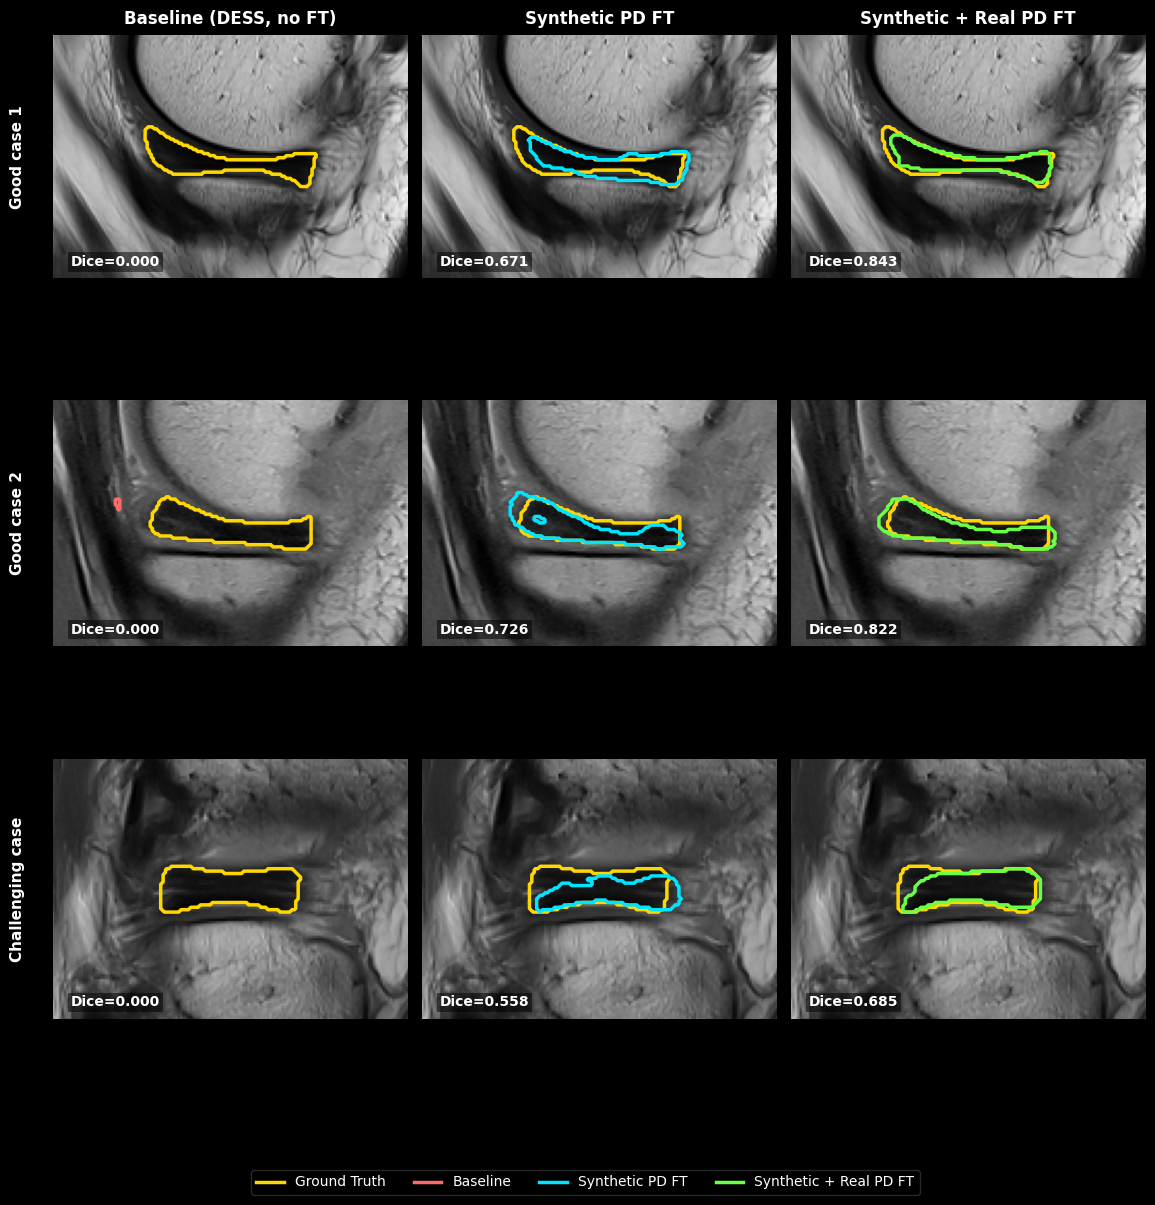

Saved → overlay_3panel_v8.png


In [12]:
# ── Plot 3: Overlay 3-panel — GT+Base | GT+Syn | GT+Syn+Real ────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 14), facecolor="black")
fig.subplots_adjust(hspace=0.06, wspace=0.04, left=0.12)

col_titles = ["Baseline (DESS, no FT)", "Synthetic PD FT", "Synthetic + Real PD FT"]
for ci, t in enumerate(col_titles):
    axes[0, ci].set_title(t, color="white", fontsize=12, fontweight="bold", pad=8)

for ri, r in enumerate(panel_results):
    gt_bin  = r["_gt"].astype(bool)
    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))
    pd_sl   = load_pd_sl(r, best_sl)
    gt_disp = gt_bin[best_sl].T
    x0, x1, y0, y1 = get_zoom_bounds(gt_disp, pad=45)

    axes[ri, 0].text(-0.08, 0.5, ROW_LABELS[ri], transform=axes[ri, 0].transAxes,
                     color="white", fontsize=11, fontweight="bold", rotation=90, va="center", ha="right")

    for ci, mk in enumerate(["baseline", "pseudoPD", "mixed"]):
        ax = axes[ri, ci]
        ax.set_facecolor("black")
        ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.axis("off")
        pred_d = get_pred_bin(r, mk, best_sl).T
        if gt_disp.any():
            ax.contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=2.5)
        if pred_d.any():
            ax.contour(pred_d, levels=[0.5], colors=[PRED_COLORS[mk]], linewidths=2.5)
        d = r.get(f"dice_{mk}", float("nan"))
        ax.text(0.05, 0.05, f"Dice={d:.3f}", transform=ax.transAxes,
                color="white", fontsize=10, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=2, edgecolor="none"))

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], color="#FFD700", lw=2.5, label="Ground Truth"),
       Line2D([0],[0], color=PRED_COLORS["baseline"],  lw=2.5, label="Baseline"),
       Line2D([0],[0], color=PRED_COLORS["pseudoPD"],  lw=2.5, label="Synthetic PD FT"),
       Line2D([0],[0], color=PRED_COLORS["mixed"],     lw=2.5, label="Synthetic + Real PD FT")]
fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=10,
           framealpha=0.2, labelcolor="white", facecolor="black", bbox_to_anchor=(0.5, 0.01))
plt.savefig(f"{BASE}/overlay_3panel_v8.png", dpi=150, facecolor="black", bbox_inches="tight")
plt.show()
print("Saved → overlay_3panel_v8.png")

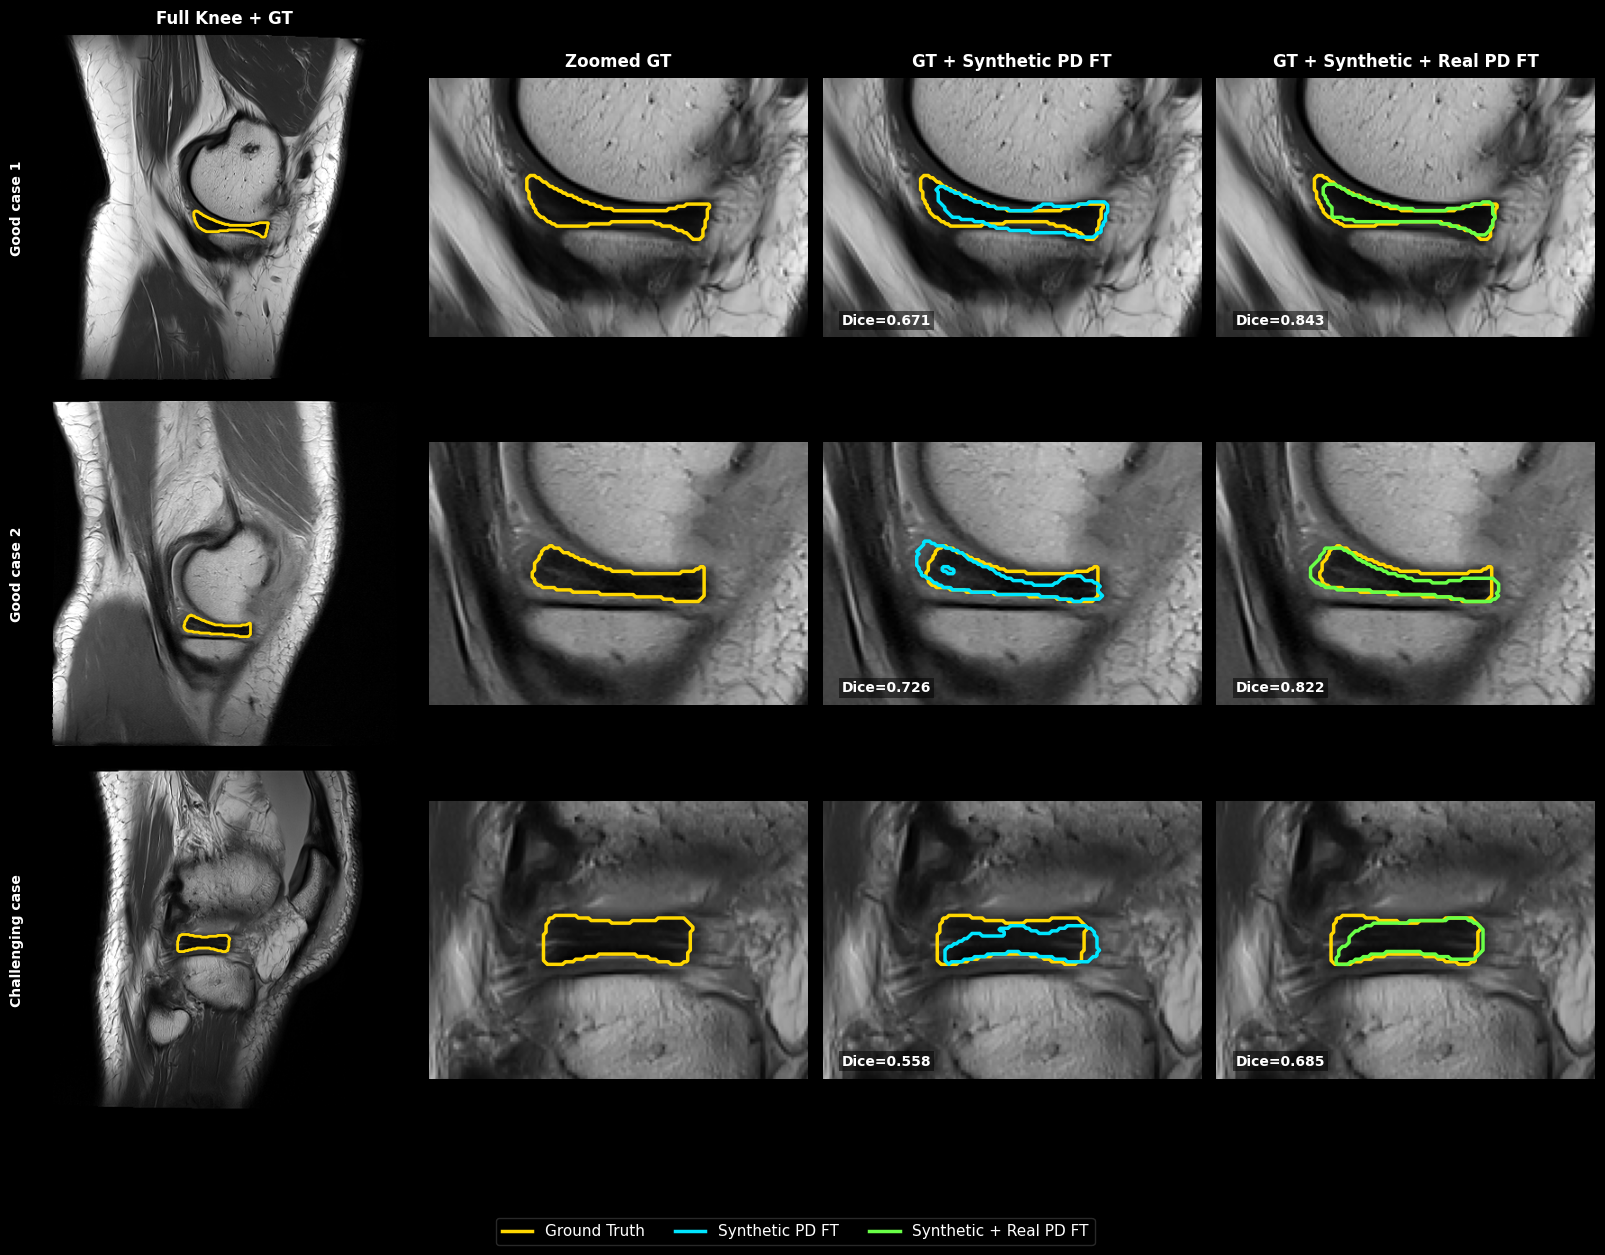

Saved → zoom_fullknee_v8.png


In [13]:
# ── Plot 4: Full knee+GT | Zoomed GT | GT+Syn | GT+Syn+Real ─────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 14), facecolor="black")
fig.subplots_adjust(hspace=0.06, wspace=0.04, left=0.12)

col_titles = ["Full Knee + GT", "Zoomed GT", "GT + Synthetic PD FT", "GT + Synthetic + Real PD FT"]
for ci, t in enumerate(col_titles):
    axes[0, ci].set_title(t, color="white", fontsize=12, fontweight="bold", pad=8)

for ri, r in enumerate(panel_results):
    gt_bin  = r["_gt"].astype(bool)
    best_sl = int(np.argmax(gt_bin.sum(axis=(1, 2))))
    pd_sl   = load_pd_sl(r, best_sl)
    gt_disp = gt_bin[best_sl].T
    x0, x1, y0, y1 = get_zoom_bounds(gt_disp, pad=45)

    axes[ri, 0].text(-0.08, 0.5, ROW_LABELS[ri], transform=axes[ri, 0].transAxes,
                     color="white", fontsize=10, fontweight="bold", rotation=90, va="center", ha="right")

    # Col 0: full knee + GT
    ax0 = axes[ri, 0]
    ax0.set_facecolor("black"); ax0.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1); ax0.axis("off")
    if gt_disp.any(): ax0.contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=2.0)

    # Col 1: zoomed GT
    ax1 = axes[ri, 1]
    ax1.set_facecolor("black"); ax1.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax1.set_xlim(x0, x1); ax1.set_ylim(y0, y1); ax1.axis("off")
    if gt_disp.any(): ax1.contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=2.5)

    # Cols 2-3: GT + prediction
    for ci, mk in enumerate(["pseudoPD", "mixed"], start=2):
        ax = axes[ri, ci]
        ax.set_facecolor("black"); ax.imshow(pd_sl.T, cmap="gray", origin="lower", vmin=0, vmax=1)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.axis("off")
        pred_d = get_pred_bin(r, mk, best_sl).T
        if gt_disp.any(): ax.contour(gt_disp, levels=[0.5], colors=["#FFD700"], linewidths=2.5)
        if pred_d.any(): ax.contour(pred_d, levels=[0.5], colors=[PRED_COLORS[mk]], linewidths=2.5)
        d = r.get(f"dice_{mk}", float("nan"))
        ax.text(0.05, 0.05, f"Dice={d:.3f}", transform=ax.transAxes,
                color="white", fontsize=10, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=2, edgecolor="none"))

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], color="#FFD700", lw=2.5, label="Ground Truth"),
       Line2D([0],[0], color=PRED_COLORS["pseudoPD"], lw=2.5, label="Synthetic PD FT"),
       Line2D([0],[0], color=PRED_COLORS["mixed"],    lw=2.5, label="Synthetic + Real PD FT")]
fig.legend(handles=leg, loc="lower center", ncol=3, fontsize=11,
           framealpha=0.2, labelcolor="white", facecolor="black", bbox_to_anchor=(0.5, 0.01))
plt.savefig(f"{BASE}/zoom_fullknee_v8.png", dpi=150, facecolor="black", bbox_inches="tight")
plt.show()
print("Saved → zoom_fullknee_v8.png")